# 02 - IEEE-CIS Predictive Model Benchmarks

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"

GIT_COMMIT = None
if KAGGLE:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': '4c812b10a35a517e3726ad672304f2fdd2c14242', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

- PR-AUC is the primary metric.
- F2 is the default operating-threshold objective.
- Full mode repeats the benchmark over three independent seeds.
- Quick mode is an explicit smoke test, not thesis evidence.

In [2]:
from src.experiment import run_repeated_predictive_benchmarks

output_dir = OUTPUT_BASE / "02_ieee_cis_model_benchmarks"
result = run_repeated_predictive_benchmarks(
    PROJECT_ROOT / "configs/ieee_cis.yaml",
    output_dir=output_dir,
    model_names=("mlp", "tabular_resnet", "tree"),
    quick_run=QUICK_RUN,
    synthetic_fallback=ALLOW_SYNTHETIC_FALLBACK,
)
metrics = result["metrics"]
summary = result["summary"]
print({"data_sources": result["data_sources"], "seeds": result["seeds"], "output_dir": str(output_dir)})
display(summary.round(4))

{'data_sources': ['real'], 'seeds': [42, 123, 2026], 'output_dir': '/kaggle/working/thesis_outputs/02_ieee_cis_model_benchmarks'}


,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,n_seeds
0,MLP,mlp,test,0.3629,0.0098,0.8051,0.0020,0.2583,0.0073,0.5102,0.0026,0.3429,0.0062,0.4269,0.0036,0.1016,0.0057,0.1915,0.0058,0.3421,0.0124,0.6955,0.0131,0.0688,0.0021,3
1,MLP,mlp,validation,0.4163,0.0036,0.8320,0.0014,0.2867,0.0094,0.5448,0.0079,0.3755,0.0062,0.4615,0.0007,0.0925,0.0029,0.1770,0.0034,0.3154,0.0078,0.6955,0.0131,0.0653,0.0031,3
2,TabularResNet,tabular_resnet,test,0.3380,0.0152,0.7892,0.0072,0.2644,0.0165,0.4673,0.0432,0.3365,0.0068,0.4039,0.0202,0.1213,0.0186,0.1774,0.0285,0.4031,0.0502,0.8455,0.0605,0.0619,0.0089,3
3,TabularResNet,tabular_resnet,validation,0.4057,0.0067,0.8147,0.0046,0.3099,0.0137,0.4920,0.0235,0.3798,0.0045,0.4398,0.0099,0.1042,0.0081,0.1563,0.0167,0.3525,0.0219,0.8455,0.0605,0.0547,0.0050,3
4,xgboost,tree,test,0.4565,0.0017,0.8744,0.0032,0.2827,0.0109,0.5705,0.0255,0.3777,0.0048,0.4736,0.0090,0.0329,0.0017,0.0527,0.0068,0.1338,0.0061,0.2941,0.0372,0.0704,0.0056,3
5,xgboost,tree,validation,0.5353,0.0047,0.9061,0.0033,0.3316,0.0131,0.6360,0.0270,0.4355,0.0047,0.5368,0.0090,0.0288,0.0016,0.0504,0.0067,0.1199,0.0063,0.2941,0.0372,0.0660,0.0053,3


## Data

In [3]:
display(result["data_summary"])

,split,rows,fraud_rate
0,train,413378,0.035169
1,validation,88581,0.034341
2,test,88581,0.034804


## Results

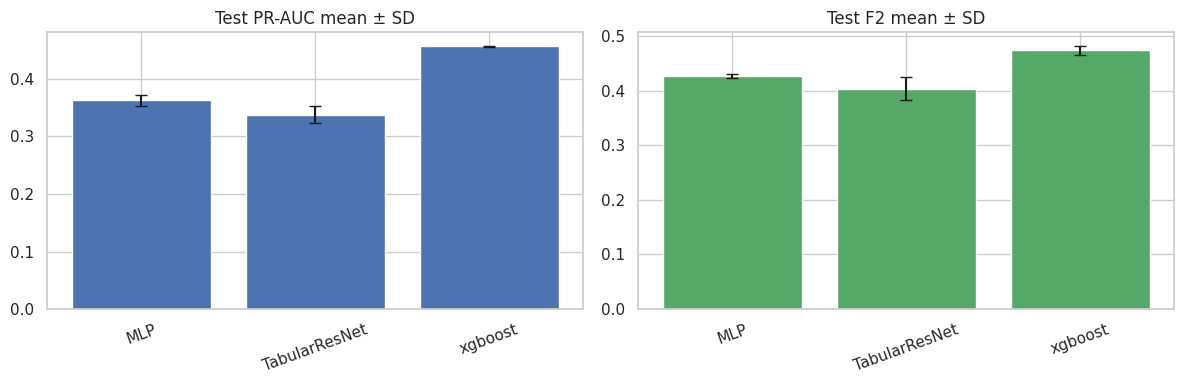

In [4]:
test_metrics = summary.query("split == 'test'").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(test_metrics["model"], test_metrics["pr_auc_mean"], yerr=test_metrics["pr_auc_std"].fillna(0), color="#4C72B0", capsize=4)
axes[0].set_title("Test PR-AUC mean ± SD")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(test_metrics["model"], test_metrics["fbeta_mean"], yerr=test_metrics["fbeta_std"].fillna(0), color="#55A868", capsize=4)
axes[1].set_title("Test F2 mean ± SD")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(output_dir / "predictive_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
for seed, model_histories in result["histories"].items():
    for model_name, history in model_histories.items():
        display(Markdown(f"### {model_name} training history - seed {seed}"))
        display(pd.DataFrame(history))

### mlp training history - seed 42

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.193502,0.170358,0.000043
1,2.0,1.094710,0.234758,0.000050
2,3.0,1.058337,0.260355,0.000064
3,4.0,1.035822,0.270027,0.000082
4,5.0,1.014333,0.280476,0.000104
...,...,...,...,...
82,83.0,0.565594,0.406712,0.000139
83,84.0,0.564678,0.410262,0.000123
84,85.0,0.564491,0.411492,0.000109
85,86.0,0.562928,0.407295,0.000095


### tabular_resnet training history - seed 42

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.140823,0.218964,0.000041
1,2.0,1.035737,0.256533,0.000045
2,3.0,1.005716,0.273132,0.000050
3,4.0,0.982050,0.291507,0.000059
4,5.0,0.964845,0.299292,0.000069
...,...,...,...,...
70,71.0,0.386040,0.388766,0.000856
71,72.0,0.379596,0.395618,0.000845
72,73.0,0.379423,0.348595,0.000835
73,74.0,0.371857,0.389948,0.000823


### mlp training history - seed 123

...

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.133007,0.263033,0.000041
1,2.0,1.033123,0.281491,0.000045
2,3.0,1.002801,0.293378,0.000050
3,4.0,0.981130,0.304956,0.000059
4,5.0,0.965364,0.303241,0.000069
...,...,...,...,...
84,85.0,0.324259,0.358534,0.000683
85,86.0,0.324850,0.384765,0.000669
86,87.0,0.314015,0.374856,0.000654
87,88.0,0.315593,0.389854,0.000640


### mlp training history - seed 2026

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.191379,0.175748,0.000043
1,2.0,1.098028,0.241916,0.000050
2,3.0,1.061994,0.269247,0.000064
3,4.0,1.037021,0.278015,0.000082
4,5.0,1.012747,0.284533,0.000104
...,...,...,...,...
92,93.0,0.549812,0.411678,0.000024
93,94.0,0.550660,0.411526,0.000018
94,95.0,0.550321,0.411715,0.000013
95,96.0,0.547590,0.411702,0.000008


### tabular_resnet training history - seed 2026

,epoch,train_loss,validation_pr_auc,learning_rate
0,1.0,1.144553,0.253381,0.000041
1,2.0,1.042303,0.269348,0.000045
2,3.0,1.008669,0.281864,0.000050
3,4.0,0.987953,0.290645,0.000059
4,5.0,0.969504,0.297935,0.000069
...,...,...,...,...
71,72.0,0.376948,0.394986,0.000845
72,73.0,0.371066,0.385640,0.000835
73,74.0,0.368181,0.386380,0.000823
74,75.0,0.363275,0.398064,0.000812


## Takeaways

In [6]:
best = test_metrics.sort_values("pr_auc_mean", ascending=False).iloc[0]
display(Markdown(
    f"- Data source: **{', '.join(result['data_sources'])}**.\n"
    f"- Seeds: **{result['seeds']}**.\n"
    f"- Highest mean test PR-AUC: **{best['model']} = {best['pr_auc_mean']:.4f} ± {best['pr_auc_std']:.4f}**.\n"
    f"- Mean locked-threshold F2: **{best['fbeta_mean']:.4f} ± {best['fbeta_std']:.4f}**.\n"
    "- Interpret only real-data, non-quick runs as thesis evidence."
))

- Data source: **real**.
- Seeds: **[42, 123, 2026]**.
- Highest mean test PR-AUC: **xgboost = 0.4565 ± 0.0017**.
- Mean locked-threshold F2: **0.4736 ± 0.0090**.
- Interpret only real-data, non-quick runs as thesis evidence.